# Optimization Algorithms for Ridge Regression
## Pokémon case study with correlated predictors

This corrected version preserves the scope of the original MSc coursework:
Ridge Regression is solved with optimization algorithms implemented explicitly,
while SciPy's SLSQP is used only as a reference solver.

The optimizer structures were supplied in the course and were adapted here for
the Pokémon case study, parameter experiments, numerical safeguards and fair
evaluation.

## 1. Data loading and preparation

The source CSV contains the same 800-row block four times and also includes
alternative forms that share a National Pokédex number. Exact duplicates are
removed first, followed by retaining one base record per Pokédex number. This
leaves 721 unique Pokémon species before the train/test split.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
np.set_printoptions(precision=6, suppress=True)

RANDOM_STATE = 42
LAMBDA_REG = 1.0
SOURCE_DATA_PATH = r"E:\data\pokemon.csv"

In [2]:
pokemon_data = pd.read_csv(SOURCE_DATA_PATH)
rows_before_cleaning = len(pokemon_data)

# Remove the four repeated copies of the dataset.
pokemon_data = pokemon_data.drop_duplicates()
rows_after_exact_deduplication = len(pokemon_data)

# Keep one base form for each National Pokédex number.
pokemon_data = (
    pokemon_data
    .drop_duplicates(subset="#", keep="first")
    .reset_index(drop=True)
)

print(f"Rows before cleaning: {rows_before_cleaning}")
print(f"Rows after exact duplicate removal: {rows_after_exact_deduplication}")
print(f"Unique Pokémon species: {len(pokemon_data)}")

Rows before cleaning: 3200
Rows after exact duplicate removal: 800
Unique Pokémon species: 721


In [3]:
features = ["HP", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
target = "Attack"

columns_to_drop = ["#", "Name", "Generation", "Total"]
model_data = pokemon_data.drop(columns=columns_to_drop)

X = model_data[features].to_numpy(dtype=float)
y = model_data[target].to_numpy(dtype=float)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

y_train_mean = np.mean(y_train)
y_train_std = np.std(y_train)
y_train_normalized = (y_train - y_train_mean) / y_train_std
y_test_normalized = (y_test - y_train_mean) / y_train_std

print(f"Training rows: {len(y_train)}")
print(f"Test rows: {len(y_test)}")
print("Feature means in the scaled training set:", X_train_normalized.mean(axis=0))

Training rows: 576
Test rows: 145
Feature means in the scaled training set: [ 0. -0.  0.  0.  0.]


### Correlation and condition-number diagnosis

The correlation matrix provides a direct numerical view of relationships among
the predictors. The condition number is computed on the standardized design
matrix so that it is not dominated by different measurement scales. For this
dataset, the relationships are moderate rather than evidence of severe
multicollinearity.

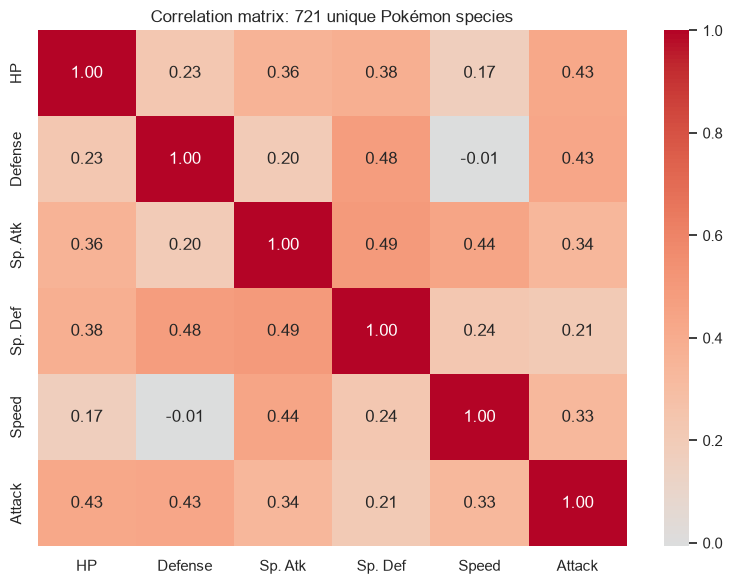

Condition number of standardized X: 2.365
Condition number of XᵀX: 5.594


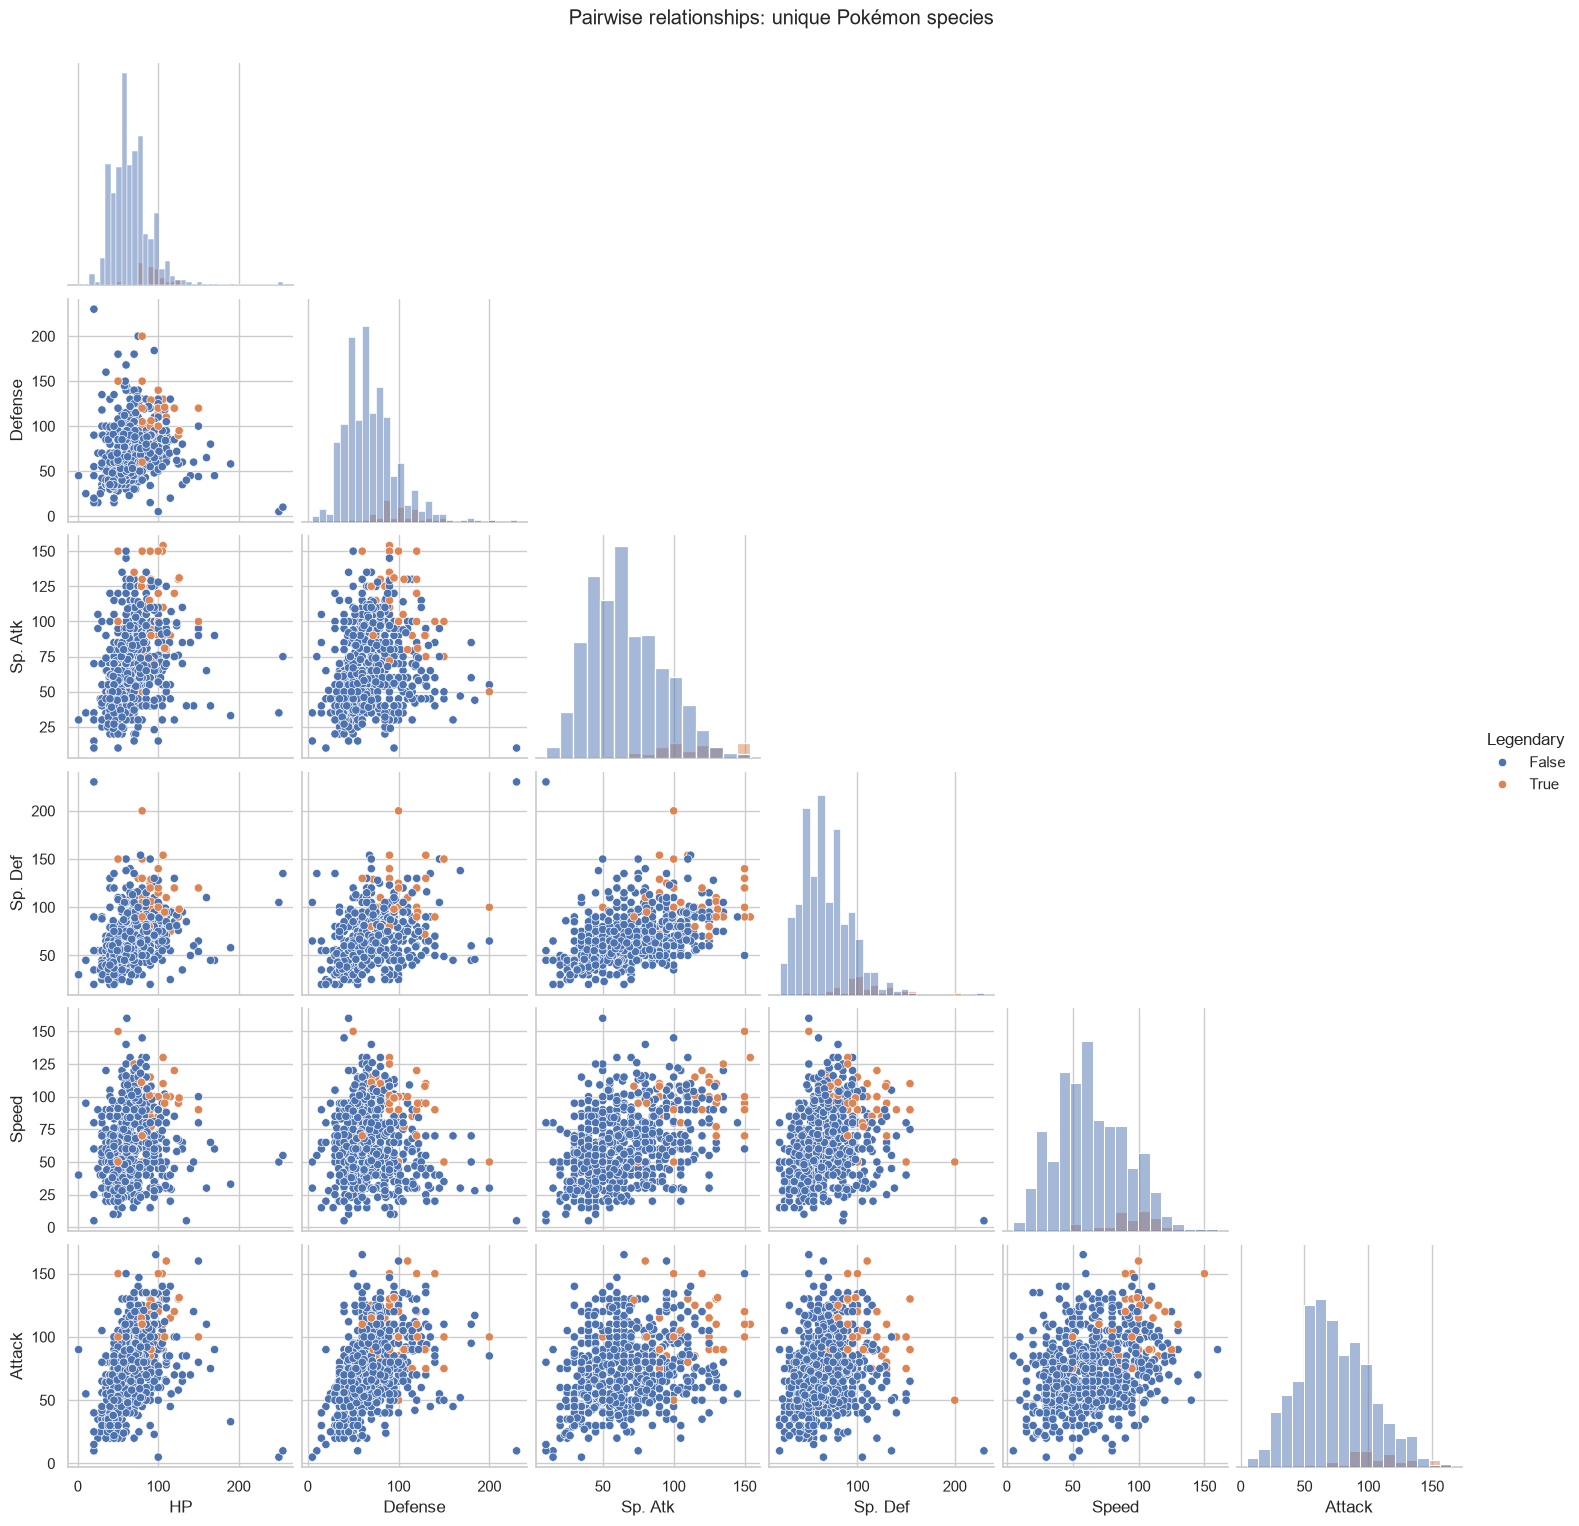

In [4]:
analysis_columns = features + [target]
correlation_matrix = pokemon_data[analysis_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix: 721 unique Pokémon species")
plt.tight_layout()
plt.show()

X_all_normalized = StandardScaler().fit_transform(pokemon_data[features])
condition_number = np.linalg.cond(X_all_normalized)
gram_condition_number = np.linalg.cond(X_all_normalized.T @ X_all_normalized)

print(f"Condition number of standardized X: {condition_number:.3f}")
print(f"Condition number of XᵀX: {gram_condition_number:.3f}")

pair_grid = sns.pairplot(
    pokemon_data,
    vars=analysis_columns,
    hue="Legendary",
    corner=True,
    diag_kind="hist",
)
pair_grid.fig.suptitle("Pairwise relationships: unique Pokémon species", y=1.02)
plt.show()

## 2. Ridge objective, gradient and Hessian

All penalized methods use the same objective and the same value
$\lambda=1$:

$$
J(w)=\frac{1}{2}\|Xw-y\|_2^2+\frac{\lambda}{2}\|w\|_2^2.
$$

Therefore

$$
\nabla J(w)=X^\top(Xw-y)+\lambda w,
\qquad
\nabla^2J(w)=X^\top X+\lambda I.
$$

The numerical derivatives are retained as an educational validation, while the
optimizers use the exact derivatives of this quadratic objective to avoid
finite-difference cancellation.

In [5]:
def ridge_cost(w, X, y, lambda_reg):
    residuals = X @ w - y
    return 0.5 * residuals @ residuals + 0.5 * lambda_reg * (w @ w)


def ridge_gradient(w, X, y, lambda_reg):
    return X.T @ (X @ w - y) + lambda_reg * w


def ridge_hessian(w, X, y, lambda_reg):
    return X.T @ X + lambda_reg * np.eye(X.shape[1])


def numerical_gradient(f, x, step=1e-6):
    gradient = np.zeros_like(x, dtype=float)
    for i in range(len(x)):
        x_right = x.copy()
        x_left = x.copy()
        x_right[i] += step
        x_left[i] -= step
        gradient[i] = (f(x_right) - f(x_left)) / (2.0 * step)
    return gradient


def numerical_hessian(f, x, step=1e-4):
    n = len(x)
    hessian = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            e_i = np.zeros(n)
            e_j = np.zeros(n)
            e_i[i] = step
            e_j[j] = step
            hessian[i, j] = (
                f(x + e_i + e_j)
                - f(x + e_i - e_j)
                - f(x - e_i + e_j)
                + f(x - e_i - e_j)
            ) / (4.0 * step**2)
    return hessian

In [6]:
# Functions for the normalized training data
def normalized_training_cost(w):
    return ridge_cost(
        w,
        X_train_normalized,
        y_train_normalized,
        LAMBDA_REG,
    )


def normalized_training_gradient(w):
    return ridge_gradient(
        w,
        X_train_normalized,
        y_train_normalized,
        LAMBDA_REG,
    )


def normalized_training_hessian(w):
    return ridge_hessian(
        w,
        X_train_normalized,
        y_train_normalized,
        LAMBDA_REG,
    )


initial_weights = np.zeros(X_train_normalized.shape[1])

numerical_grad = numerical_gradient(
    normalized_training_cost,
    initial_weights,
)
analytical_grad = normalized_training_gradient(initial_weights)
gradient_error = np.linalg.norm(numerical_grad - analytical_grad)

numerical_hess = numerical_hessian(
    normalized_training_cost,
    initial_weights,
)
analytical_hess = normalized_training_hessian(initial_weights)
hessian_error = np.linalg.norm(numerical_hess - analytical_hess)

closed_form_weights = np.linalg.solve(
    X_train_normalized.T @ X_train_normalized
    + LAMBDA_REG * np.eye(X_train_normalized.shape[1]),
    X_train_normalized.T @ y_train_normalized,
)

largest_eigenvalue = np.linalg.eigvalsh(analytical_hess).max()
safe_learning_rate = 0.9 / largest_eigenvalue

print(f"Gradient validation error: {gradient_error:.3e}")
print(f"Hessian validation error: {hessian_error:.3e}")
print(f"Largest Hessian eigenvalue: {largest_eigenvalue:.3f}")
print(f"Safe GD learning rate: {safe_learning_rate:.6f}")
print("\nClosed-form Ridge weights:")
print(closed_form_weights)

Gradient validation error: 3.664e-08
Hessian validation error: 1.073e-05
Largest Hessian eigenvalue: 1257.042
Safe GD learning rate: 0.000716

Closed-form Ridge weights:
[ 0.322748  0.482515  0.133886 -0.278899  0.29129 ]


## 3. Gradient Descent

The original run used a learning rate above the stability limit and a
finite-difference step of $10^{-14}$. Here the learning rate is derived from
the largest Hessian eigenvalue and convergence is checked with the exact
gradient norm.

In [7]:
def gradient_descent(f, grad, x0, alpha, tolerance=1e-8, max_iter=10_000):
    x = x0.astype(float).copy()
    history = [f(x)]

    for iteration in range(1, max_iter + 1):
        gradient = grad(x)
        x = x - alpha * gradient
        history.append(f(x))

        if np.linalg.norm(grad(x)) <= tolerance:
            return x, f(x), iteration, np.asarray(history), True

    return x, f(x), max_iter, np.asarray(history), False


gd_weights, gd_loss, gd_iterations, gd_history, gd_converged = gradient_descent(
    normalized_training_cost,
    normalized_training_gradient,
    initial_weights,
    alpha=safe_learning_rate,
)

print("Optimized weights:", gd_weights)
print(f"Final loss: {gd_loss:.10f}")
print(f"Iterations: {gd_iterations}")
print(f"Converged: {gd_converged}")
print(f"Distance from closed form: {np.linalg.norm(gd_weights - closed_form_weights):.3e}")

Optimized weights: [ 0.322748  0.482515  0.133886 -0.278899  0.29129 ]
Final loss: 165.3120828050
Iterations: 123
Converged: True
Distance from closed form: 3.683e-11


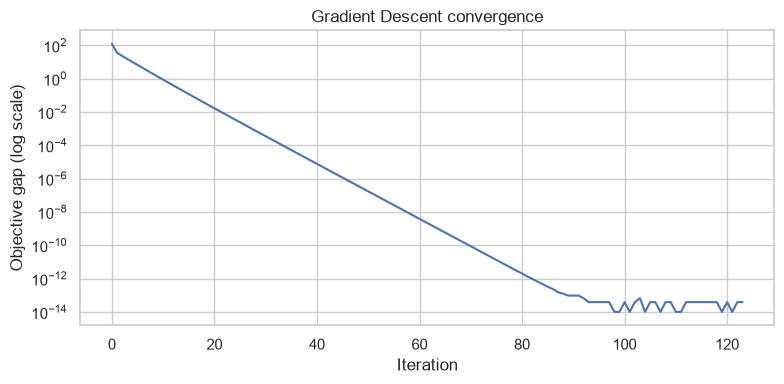

In [8]:
plt.figure(figsize=(8, 4))
plt.semilogy(gd_history - gd_history.min() + 1e-14)
plt.xlabel("Iteration")
plt.ylabel("Objective gap (log scale)")
plt.title("Gradient Descent convergence")
plt.tight_layout()
plt.show()

## 4. Newton method on non-normalized data

Following the course instruction, Newton is applied to the raw training data.
Its loss and MSE are therefore reported in the original Attack scale and are
not directly compared with the normalized results of the other methods.

Because Ridge Regression has a quadratic objective with a constant exact
Hessian, Newton should reach the minimizer in one update, up to floating-point
precision.

In [9]:
def newton_method(f, grad, hess, x0, tolerance=1e-8, max_iter=100):
    x = x0.astype(float).copy()
    history = [f(x)]

    for iteration in range(max_iter + 1):
        gradient = grad(x)
        if np.linalg.norm(gradient) <= tolerance:
            return x, f(x), iteration, np.asarray(history), True

        step = np.linalg.solve(hess(x), gradient)
        x = x - step
        history.append(f(x))

    return x, f(x), max_iter, np.asarray(history), False


def raw_training_cost(w):
    return ridge_cost(w, X_train, y_train, LAMBDA_REG)


def raw_training_gradient(w):
    return ridge_gradient(w, X_train, y_train, LAMBDA_REG)


def raw_training_hessian(w):
    return ridge_hessian(w, X_train, y_train, LAMBDA_REG)


raw_initial_weights = np.zeros(X_train.shape[1])

(
    newton_raw_weights,
    newton_raw_loss,
    newton_raw_iterations,
    newton_raw_history,
    newton_raw_converged,
) = newton_method(
    raw_training_cost,
    raw_training_gradient,
    raw_training_hessian,
    raw_initial_weights,
)

raw_closed_form_weights = np.linalg.solve(
    X_train.T @ X_train + LAMBDA_REG * np.eye(X_train.shape[1]),
    X_train.T @ y_train,
)

print("Optimized raw-data weights:", newton_raw_weights)
print(f"Final raw-data loss: {newton_raw_loss:.6f}")
print(f"Iterations: {newton_raw_iterations}")
print(f"Converged: {newton_raw_converged}")
print(
    "Distance from raw closed form:",
    f"{np.linalg.norm(newton_raw_weights - raw_closed_form_weights):.3e}",
)

Optimized raw-data weights: [ 0.389966  0.508368  0.142944 -0.295757  0.337571]
Final raw-data loss: 143731.607867
Iterations: 1
Converged: True
Distance from raw closed form: 0.000e+00


## 5. Symmetric Rank-One (SR1) Quasi-Newton

The inverse-Hessian SR1 update now includes the standard denominator safeguard.
Backtracking line search replaces the previously unused line-search expression
and the hard-coded full step.

In [10]:
def backtracking_line_search(f, grad, x, direction, initial_step=1.0, c=1e-4, shrink=0.5):
    step = initial_step
    current_value = f(x)
    directional_derivative = grad(x) @ direction
    while f(x + step * direction) > current_value + c * step * directional_derivative:
        step *= shrink
        if step < 1e-12:
            break
    return step


def sr1_quasi_newton(f, grad, x0, tolerance=1e-8, max_iter=1_000):
    x = x0.astype(float).copy()
    inverse_hessian = np.eye(len(x))
    history = [f(x)]

    for iteration in range(1, max_iter + 1):
        gradient_old = grad(x)
        if np.linalg.norm(gradient_old) <= tolerance:
            return x, f(x), iteration - 1, np.asarray(history), True

        direction = -inverse_hessian @ gradient_old
        if gradient_old @ direction >= 0:
            inverse_hessian = np.eye(len(x))
            direction = -gradient_old

        step_size = backtracking_line_search(f, grad, x, direction)
        x_new = x + step_size * direction
        gradient_new = grad(x_new)

        delta_x = x_new - x
        delta_gradient = gradient_new - gradient_old
        correction = delta_x - inverse_hessian @ delta_gradient
        denominator = correction @ delta_gradient

        safeguard = 1e-8 * np.linalg.norm(correction) * np.linalg.norm(delta_gradient)
        if abs(denominator) > safeguard:
            inverse_hessian += np.outer(correction, correction) / denominator

        x = x_new
        history.append(f(x))

        if np.linalg.norm(gradient_new) <= tolerance:
            return x, f(x), iteration, np.asarray(history), True

    return x, f(x), max_iter, np.asarray(history), False


sr1_weights, sr1_loss, sr1_iterations, sr1_history, sr1_converged = sr1_quasi_newton(
    normalized_training_cost,
    normalized_training_gradient,
    initial_weights,
)

print("Optimized weights:", sr1_weights)
print(f"Final loss: {sr1_loss:.10f}")
print(f"Iterations: {sr1_iterations}")
print(f"Converged: {sr1_converged}")
print(f"Distance from closed form: {np.linalg.norm(sr1_weights - closed_form_weights):.3e}")

Optimized weights: [ 0.322748  0.482515  0.133886 -0.278899  0.29129 ]
Final loss: 165.3120828050
Iterations: 6
Converged: True
Distance from closed form: 9.323e-15


## 6. AdaGrad

AdaGrad now solves the same penalized Ridge problem with $\lambda=1$. The
denominator stabilizer and the convergence tolerance are separate parameters.

In [11]:
def adagrad(
    f,
    grad,
    x0,
    learning_rate=0.5,
    stabilizer=1e-8,
    tolerance=1e-6,
    max_iter=50_000,
):
    x = x0.astype(float).copy()
    accumulated_squared_gradient = np.zeros_like(x)
    history = [f(x)]

    for iteration in range(1, max_iter + 1):
        gradient = grad(x)
        if np.linalg.norm(gradient) <= tolerance:
            return x, f(x), iteration - 1, np.asarray(history), True

        accumulated_squared_gradient += gradient**2
        adjusted_gradient = gradient / (np.sqrt(accumulated_squared_gradient) + stabilizer)
        x = x - learning_rate * adjusted_gradient
        history.append(f(x))

    return x, f(x), max_iter, np.asarray(history), False


adagrad_weights, adagrad_loss, adagrad_iterations, adagrad_history, adagrad_converged = adagrad(
    normalized_training_cost,
    normalized_training_gradient,
    initial_weights,
)

print("Optimized weights:", adagrad_weights)
print(f"Final loss: {adagrad_loss:.10f}")
print(f"Iterations: {adagrad_iterations}")
print(f"Converged: {adagrad_converged}")
print(f"Distance from closed form: {np.linalg.norm(adagrad_weights - closed_form_weights):.3e}")

Optimized weights: [ 0.322748  0.482515  0.133886 -0.278899  0.29129 ]
Final loss: 165.3120828050
Iterations: 82
Converged: True
Distance from closed form: 3.533e-09


## 7. Simplified Trust-Region method

This remains an educational simplified trust-region implementation: it uses a
Newton step and scales it to the radius when necessary. The predicted reduction
now uses the complete quadratic model.

In [12]:
def simplified_trust_region(
    f,
    grad,
    hess,
    x0,
    initial_radius=1.0,
    maximum_radius=10.0,
    tolerance=1e-8,
    max_iter=1_000,
):
    x = x0.astype(float).copy()
    radius = initial_radius
    history = [f(x)]

    for iteration in range(1, max_iter + 1):
        gradient = grad(x)
        if np.linalg.norm(gradient) <= tolerance:
            return x, f(x), iteration - 1, np.asarray(history), True

        hessian = hess(x)
        step = -np.linalg.solve(hessian + 1e-10 * np.eye(len(x)), gradient)
        step_norm = np.linalg.norm(step)
        on_boundary = step_norm > radius
        if on_boundary:
            step *= radius / step_norm

        predicted_reduction = -(
            gradient @ step + 0.5 * step @ hessian @ step
        )
        actual_reduction = f(x) - f(x + step)
        ratio = actual_reduction / predicted_reduction if predicted_reduction > 0 else -np.inf

        if ratio < 0.25:
            radius *= 0.25
        elif ratio > 0.75 and on_boundary:
            radius = min(2.0 * radius, maximum_radius)

        if ratio > 0:
            x = x + step
            history.append(f(x))

        if np.linalg.norm(grad(x)) <= tolerance:
            return x, f(x), iteration, np.asarray(history), True

    return x, f(x), max_iter, np.asarray(history), False


trust_weights, trust_loss, trust_iterations, trust_history, trust_converged = simplified_trust_region(
    normalized_training_cost,
    normalized_training_gradient,
    normalized_training_hessian,
    initial_weights,
)

print("Optimized weights:", trust_weights)
print(f"Final loss: {trust_loss:.10f}")
print(f"Iterations: {trust_iterations}")
print(f"Converged: {trust_converged}")
print(f"Distance from closed form: {np.linalg.norm(trust_weights - closed_form_weights):.3e}")

Optimized weights: [ 0.322748  0.482515  0.133886 -0.278899  0.29129 ]
Final loss: 165.3120828050
Iterations: 1
Converged: True
Distance from closed form: 2.474e-13


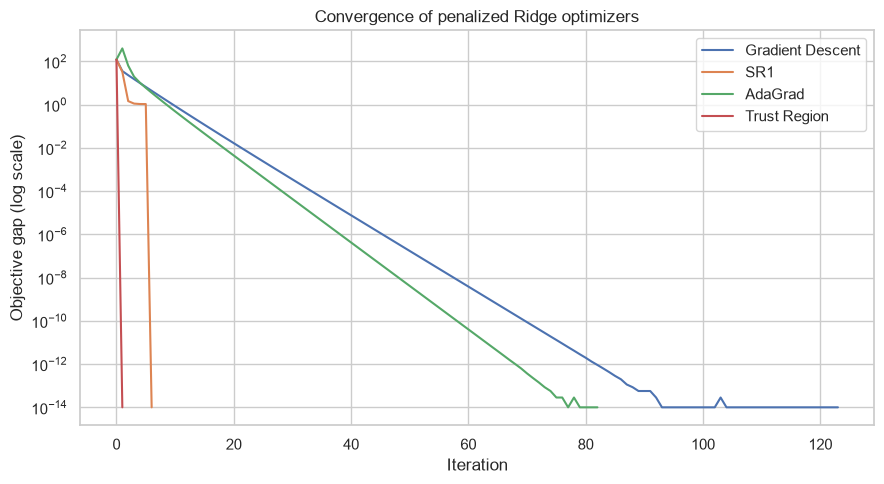

In [13]:
plt.figure(figsize=(9, 5))

method_histories = {
    "Gradient Descent": gd_history,
    "SR1": sr1_history,
    "AdaGrad": adagrad_history,
    "Trust Region": trust_history,
}

optimal_training_loss = normalized_training_cost(closed_form_weights)

for method_name, loss_history in method_histories.items():
    objective_gap = loss_history - optimal_training_loss
    plt.semilogy(np.maximum(objective_gap, 1e-14), label=method_name)

plt.xlabel("Iteration")
plt.ylabel("Objective gap (log scale)")
plt.title("Convergence of penalized Ridge optimizers")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Constrained least squares with Projected Gradient Descent

To demonstrate the constrained form correctly, the Ridge penalty is removed
from the objective and replaced by

$$
\|w\|_2\leq a.
$$

The radius is chosen as $a=\|w_{\mathrm{Ridge}}\|_2$. For this convex problem,
the constrained solution should then match the penalized Ridge solution
associated with $\lambda=1$.

In [14]:
def project_onto_l2_ball(w, radius):
    weight_norm = np.linalg.norm(w)
    if weight_norm <= radius or weight_norm == 0:
        return w
    return radius * w / weight_norm


def projected_gradient_descent(
    f,
    grad,
    projection,
    x0,
    radius,
    alpha,
    tolerance=1e-9,
    max_iter=50_000,
):
    x = x0.astype(float).copy()
    history = [f(x)]

    for iteration in range(1, max_iter + 1):
        x_new = projection(x - alpha * grad(x), radius)
        history.append(f(x_new))

        if np.linalg.norm(x_new - x) <= tolerance:
            return x_new, f(x_new), iteration, np.asarray(history), True
        x = x_new

    return x, f(x), max_iter, np.asarray(history), False


def unregularized_training_cost(w):
    return ridge_cost(w, X_train_normalized, y_train_normalized, 0.0)


def unregularized_training_gradient(w):
    return ridge_gradient(w, X_train_normalized, y_train_normalized, 0.0)


constraint_radius = np.linalg.norm(closed_form_weights)
unregularized_lipschitz_constant = np.linalg.eigvalsh(
    X_train_normalized.T @ X_train_normalized
).max()
projected_learning_rate = 0.9 / unregularized_lipschitz_constant

(
    pgd_weights,
    pgd_unregularized_loss,
    pgd_iterations,
    pgd_history,
    pgd_converged,
) = projected_gradient_descent(
    unregularized_training_cost,
    unregularized_training_gradient,
    project_onto_l2_ball,
    initial_weights,
    radius=constraint_radius,
    alpha=projected_learning_rate,
)

print(f"Constraint radius: {constraint_radius:.8f}")
print("Optimized weights:", pgd_weights)
print(f"Unregularized constrained loss: {pgd_unregularized_loss:.10f}")
print(f"Iterations: {pgd_iterations}")
print(f"Converged: {pgd_converged}")
print(f"Final weight norm: {np.linalg.norm(pgd_weights):.8f}")
print(
    "Distance from penalized Ridge solution:",
    f"{np.linalg.norm(pgd_weights - closed_form_weights):.3e}",
)

Constraint radius: 0.71940773
Optimized weights: [ 0.322748  0.482515  0.133886 -0.278899  0.29129 ]
Unregularized constrained loss: 165.0533090639
Iterations: 85
Converged: True
Final weight norm: 0.71940773
Distance from penalized Ridge solution: 3.962e-09


## 9. SLSQP reference solver

SLSQP is not presented as Gradient Descent. It is used only to verify the same
unregularized, L2-constrained problem solved by Projected Gradient Descent.

In [15]:
def l2_ball_constraint(w):
    return constraint_radius**2 - w @ w


def l2_ball_constraint_jacobian(w):
    return -2.0 * w


slsqp_constraint = {
    "type": "ineq",
    "fun": l2_ball_constraint,
    "jac": l2_ball_constraint_jacobian,
}

slsqp_result = minimize(
    unregularized_training_cost,
    initial_weights,
    jac=unregularized_training_gradient,
    constraints=slsqp_constraint,
    method="SLSQP",
    options={"ftol": 1e-12, "maxiter": 1_000},
)

slsqp_weights = slsqp_result.x
slsqp_iterations = slsqp_result.nit

print(f"Success: {slsqp_result.success}")
print("Message:", slsqp_result.message)
print("Optimized weights:", slsqp_weights)
print(f"Unregularized constrained loss: {slsqp_result.fun:.10f}")
print(f"Iterations: {slsqp_iterations}")
print(f"Final weight norm: {np.linalg.norm(slsqp_weights):.8f}")
print(f"Distance from PGD: {np.linalg.norm(slsqp_weights - pgd_weights):.3e}")

Success: True
Message: Optimization terminated successfully
Optimized weights: [ 0.322748  0.482515  0.133886 -0.278899  0.29129 ]
Unregularized constrained loss: 165.0533090639
Iterations: 12
Final weight norm: 0.71940773
Distance from PGD: 5.083e-09


## 10. Evaluation and fair comparison

All normalized methods are evaluated on the same normalized test set. Newton's
raw-data result is shown separately in the original Attack scale. The number of
iterations describes numerical convergence; it is not evidence of overfitting.

In [16]:
def mean_squared_error_manual(w, X, y):
    residuals = X @ w - y
    return np.mean(residuals**2)


normalized_results = [
    ("Closed-form Ridge", closed_form_weights, 0, True),
    ("Gradient Descent", gd_weights, gd_iterations, gd_converged),
    ("SR1", sr1_weights, sr1_iterations, sr1_converged),
    ("AdaGrad", adagrad_weights, adagrad_iterations, adagrad_converged),
    ("Trust Region", trust_weights, trust_iterations, trust_converged),
    ("Projected GD", pgd_weights, pgd_iterations, pgd_converged),
    ("SLSQP reference", slsqp_weights, slsqp_iterations, slsqp_result.success),
]

comparison_table = pd.DataFrame(
    [
        {
            "Method": method_name,
            "Iterations": iterations,
            "Converged": converged,
            "Common Ridge objective": normalized_training_cost(weights),
            "Train MSE (normalized)": mean_squared_error_manual(
                weights,
                X_train_normalized,
                y_train_normalized,
            ),
            "Test MSE (normalized)": mean_squared_error_manual(
                weights,
                X_test_normalized,
                y_test_normalized,
            ),
            "Distance from closed form": np.linalg.norm(
                weights - closed_form_weights
            ),
        }
        for method_name, weights, iterations, converged in normalized_results
    ]
)

display(comparison_table.round(10))

newton_raw_train_mse = mean_squared_error_manual(
    newton_raw_weights,
    X_train,
    y_train,
)
newton_raw_test_mse = mean_squared_error_manual(
    newton_raw_weights,
    X_test,
    y_test,
)

print(f"Raw Newton train MSE (Attack units²): {newton_raw_train_mse:.6f}")
print(f"Raw Newton test MSE (Attack units²): {newton_raw_test_mse:.6f}")

,Method,Iterations,Converged,Common Ridge objective,Train MSE (normalized),Test MSE (normalized),Distance from closed form
0,Closed-form Ridge,0,True,165.312083,0.573102,0.521957,0.000000e+00
1,Gradient Descent,123,True,165.312083,0.573102,0.521957,0.000000e+00
2,SR1,6,True,165.312083,0.573102,0.521957,0.000000e+00
3,AdaGrad,82,True,165.312083,0.573102,0.521957,3.500000e-09
4,Trust Region,1,True,165.312083,0.573102,0.521957,0.000000e+00
5,Projected GD,85,True,165.312083,0.573102,0.521957,4.000000e-09
6,SLSQP reference,12,True,165.312083,0.573102,0.521957,1.800000e-09


Raw Newton train MSE (Attack units²): 499.066985
Raw Newton test MSE (Attack units²): 462.034161


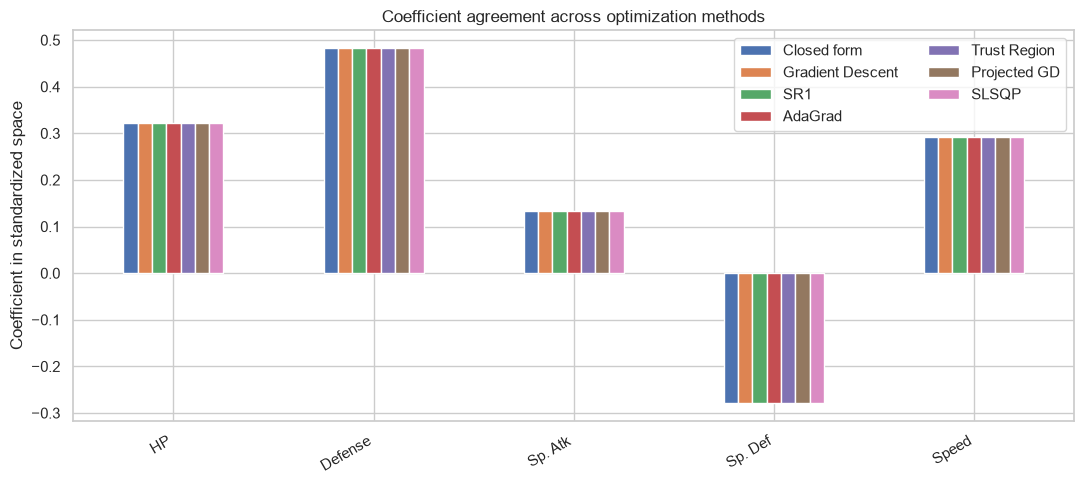

In [17]:
coefficient_table = pd.DataFrame(
    {
        "Closed form": closed_form_weights,
        "Gradient Descent": gd_weights,
        "SR1": sr1_weights,
        "AdaGrad": adagrad_weights,
        "Trust Region": trust_weights,
        "Projected GD": pgd_weights,
        "SLSQP": slsqp_weights,
    },
    index=features,
)

coefficient_table.plot(kind="bar", figsize=(11, 5))
plt.ylabel("Coefficient in standardized space")
plt.title("Coefficient agreement across optimization methods")
plt.xticks(rotation=30, ha="right")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

## Conclusions

- Removing repeated records and alternative forms prevents data leakage and
  leaves 721 unique Pokémon species.
- The selected attributes show moderate correlations rather than severe
  multicollinearity.
- Gradient Descent converges when its step respects the Hessian stability
  limit; the previous divergence was numerical, not a property of Ridge
  Regression.
- Exact Newton reaches the raw-data Ridge solution in essentially one update,
  as expected for a quadratic objective.
- SR1, AdaGrad and the simplified Trust-Region method solve the same penalized
  objective and can therefore be compared fairly.
- Projected Gradient Descent and SLSQP solve the same genuinely constrained
  least-squares problem. SLSQP is a validation benchmark, not a variant of
  Gradient Descent.
- Fast numerical convergence does not imply overfitting. Generalization is
  assessed with test performance and is influenced by the data, model and
  regularization.